# Final Gemma 4

In [1]:
import polars as pl

from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations import (
    apply_parsing_and_group_decision,
)
from social_groups.analysis.polars_transformations.wasserstein_distance import (
    calculate_wasserstein_distance,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
import social_groups.polars_columns as plc
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:398: BetaWarning: Class `Manager` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  MANAGER_FOR_NOTEBOOK_INSTANCE = Manager()
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:200: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:205: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterth

In [2]:
parser = AnswerParser(AnswerOptions.letters_A_to_D)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_D, triple_underscore_handling="wrong"
)

In [3]:
from social_groups.analysis.definitions import defs

gemma4_single_model_baseline: pl.DataFrame = defs().load_asset_value(
    "final_gemma4_single_model_baseline"
)
gemma4_no_discussion_voting: pl.DataFrame = defs().load_asset_value(
    "final_gemma4_no_discussion_voting_base"
)
gemma4_multi_agent_debate: pl.DataFrame = defs().load_asset_value(
    "final_gemma4_multi_agent_debate"
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:101: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-07-10 23:43:24 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_gemma4_single_model_baseline.parquet using PolarsParquetIOManager...
2026-07-10 23:43:24 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_gemma4_no_discussion_voting_base.parquet using PolarsParquetIOManager...
2026-07-10 23:43:24 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/fi

In [4]:
gemma4_multi_agent_debate = apply_parsing_and_group_decision(
    gemma4_multi_agent_debate, parser, comparer, group_reply
)
gemma4_no_discussion_voting = gemma4_no_discussion_voting.with_columns(
    parser(pl.col(plc.final_answer)).alias("parsed_answer")
).drop(
    "phoenix_span_url",
    "run_identifier",
    "question_id",
    "category",
    "question",
    "with_few_shot_prompting",
    "use_thinking",
    "max_new_tokens",
    "final_answer",
    "temperature",
    "top_p",
    "model_name",
)

gemma4_single_model_baseline = (
    gemma4_single_model_baseline.with_columns(
        parser(pl.col(plc.final_answer)).alias("parsed_answer")
    )
    .with_columns(
        comparer(pl.col("parsed_answer"), pl.col(plc.answer_string)).alias(
            plc.is_correct
        )
    )
    .drop(
        "phoenix_span_url",
        "run_identifier",
        "final_answer",
        "question_id",
        "category",
        "question",
        "with_few_shot_prompting",
        "use_thinking",
        "max_new_tokens",
        "temperature",
        "top_p",
        "model_name",
    )
)

In [5]:
gemma4_multi_agent_debate = gemma4_multi_agent_debate.with_columns(
    pl.col("group_constellation").alias("old_group_constellation"),
    pl.when(pl.col("thinking_openly") == "onlyH")
    .then(pl.lit("onlyH_") + pl.col("group_constellation"))
    .otherwise(
        pl.when(pl.col("thinking_openly") == "all")
        .then(pl.lit("all1st_") + pl.col("group_constellation"))
        .otherwise(pl.col("group_constellation"))
    )
    .alias("group_constellation"),
)

In [6]:
single_model_result = gemma4_single_model_baseline.group_by("seed", "model_size").agg(
    pl.col("used_input_tokens").mean(),
    pl.col("used_output_tokens").mean(),
    accuracy=pl.col("is_correct").mean(),
)
single_model_result

seed,model_size,used_input_tokens,used_output_tokens,accuracy
i64,str,f64,f64,f64
5,"""E2B""",245.045455,1551.656566,0.424242
2,"""31B""",249.045455,744.722222,0.762626
5,"""31B""",249.045455,752.5,0.767677
1,"""E4B""",245.045455,1710.873737,0.540404
1,"""E2B""",245.045455,1534.893939,0.383838
…,…,…,…,…
3,"""E4B""",245.045455,1681.636364,0.535354
2,"""E2B""",245.045455,1516.712121,0.39899
3,"""31B""",249.045455,765.111111,0.782828


In [7]:
import polars as pl


no_discussion_result = (
    gemma4_no_discussion_voting.group_by("seed", "model_size", "original_question_id")
    .agg(
        pl.col("answer_string").unique().item(),
        pl.col("parsed_answer").alias("parsed_answers"),
        pl.col("used_input_tokens").alias("used_input_tokensS"),
        pl.col("used_output_tokens").alias("used_output_tokensS"),
    )
    .join(
        pl.DataFrame({"no_participants": range(1, 10)}),
        how="cross",
    )
    .with_columns(
        group_answer=group_reply(
            pl.col("parsed_answers").list.slice(0, pl.col("no_participants"))
        ),
        used_input_tokens=pl.col("used_input_tokensS")
        .list.slice(0, pl.col("no_participants"))
        .list.sum(),
        used_output_tokens=pl.col("used_output_tokensS")
        .list.slice(0, pl.col("no_participants"))
        .list.sum(),
    )
    .with_columns(is_correct=comparer(pl.col("group_answer"), pl.col("answer_string")))
    .group_by("seed", "model_size", "no_participants")
    .agg(
        pl.col("used_input_tokens").mean(),
        pl.col("used_output_tokens").mean(),
        accuracy=pl.col("is_correct").mean(),
    )
)

no_discussion_result

seed,model_size,no_participants,used_input_tokens,used_output_tokens,accuracy
i64,str,i64,f64,f64,f64
5,"""E2B""",8,1960.363636,12295.772727,0.378788
2,"""E4B""",7,1715.318182,11688.131313,0.570707
3,"""E2B""",4,980.181818,6083.691919,0.378788
3,"""E2B""",1,245.045455,1519.989899,0.368687
5,"""E4B""",4,980.181818,7027.656566,0.545455
…,…,…,…,…,…
3,"""E4B""",1,245.045455,1698.065657,0.530303
1,"""E4B""",1,245.045455,1728.126263,0.575758
4,"""E2B""",6,1470.272727,9047.146465,0.373737


In [8]:
mad_result = (
    gemma4_multi_agent_debate.drop(
        [
            "phoenix_span_url",
            "run_identifier",
            "question_id",
            "category",
            "with_few_shot_prompting",
            "max_new_tokens",
            "top_p",
            "temperature",
            "model_names",
        ]
    )
    .group_by("seed", "model_sizes", "group_constellation")
    .agg(
        comparer(pl.col(plc.parsed_combined_answers_before), pl.col(plc.answer_string))
        .mean()
        .alias("accuracy_before"),
        comparer(pl.col(plc.parsed_combined_answers_after), pl.col(plc.answer_string))
        .mean()
        .alias("accuracy"),
        pl.col("used_input_tokens").mean(),
        pl.col("used_output_tokens").mean(),
    )
    .with_columns(accuracy_increase=pl.col("accuracy") - pl.col("accuracy_before"))
)

In [9]:
(
    single_model_result.group_by("model_size").agg(
        pl.exclude("seed").mean().name.suffix("_mean"),
        pl.exclude("seed").std().name.suffix("_std"),
    )
)

model_size,used_input_tokens_mean,used_output_tokens_mean,accuracy_mean,used_input_tokens_std,used_output_tokens_std,accuracy_std
str,f64,f64,f64,f64,f64,f64
"""E2B""",245.045455,1528.938384,0.39596,0.0,16.070207,0.021007
"""E4B""",245.045455,1703.159596,0.540404,0.0,37.569766,0.021723
"""31B""",249.045455,757.274747,0.766667,0.0,11.373146,0.009715


In [10]:
(
    no_discussion_result.group_by("model_size", "no_participants").agg(
        pl.exclude("seed").mean().name.suffix("_mean"),
        pl.exclude("seed").std().name.suffix("_std"),
    )
)

model_size,no_participants,used_input_tokens_mean,used_output_tokens_mean,accuracy_mean,used_input_tokens_std,used_output_tokens_std,accuracy_std
str,i64,f64,f64,f64,f64,f64,f64
"""E4B""",9,2205.409091,15539.573737,0.561616,0.0,306.233695,0.020012
"""E4B""",6,1470.272727,10352.70202,0.529293,0.0,214.833293,0.017275
"""E2B""",7,1715.318182,10650.777778,0.393939,0.0,84.085745,0.007142
"""E2B""",6,1470.272727,9097.412121,0.380808,0.0,55.552516,0.008451
"""E2B""",3,735.136364,4550.3,0.378788,0.0,39.825204,0.014725
…,…,…,…,…,…,…,…
"""E4B""",3,735.136364,5163.533333,0.553535,0.0,109.370482,0.019099
"""E4B""",5,1225.227273,8617.618182,0.541414,0.0,187.731141,0.014015
"""E4B""",4,980.181818,6884.361616,0.522222,0.0,138.088454,0.016598


In [11]:
(
    mad_result.group_by("group_constellation").agg(
        pl.exclude("seed").mean().name.suffix("_mean"),
        pl.exclude("seed").std().name.suffix("_std"),
    )
)

group_constellation,model_sizes_mean,accuracy_before_mean,accuracy_mean,used_input_tokens_mean,used_output_tokens_mean,accuracy_increase_mean,model_sizes_std,accuracy_before_std,accuracy_std,used_input_tokens_std,used_output_tokens_std,accuracy_increase_std
str,list[str],f64,f64,f64,f64,f64,list[str],f64,f64,f64,f64,f64
"""all1st_LLH""",null,0.421212,0.544444,32704.994949,9106.782828,0.123232,null,0.012163,0.017275,128.360771,125.644349,0.017349
"""onlyH_LLH""",null,0.413131,0.532323,19633.735354,9489.00303,0.119192,null,0.014462,0.017349,258.816493,113.575791,0.019099
"""onlyH_HHH""",null,0.549495,0.578788,36023.415152,10240.575758,0.029293,null,0.020012,0.024379,600.790152,151.762375,0.026581
"""all1st_LHH""",null,0.517172,0.573737,34379.175758,9678.658586,0.056566,null,0.013646,0.01943,393.777586,143.865439,0.021248
"""onlyH_LLL""",null,0.394949,0.427273,11188.047475,9644.931313,0.032323,null,0.006585,0.012677,210.808329,167.856187,0.007659
…,…,…,…,…,…,…,…,…,…,…,…,…
"""HHH""",null,0.542424,0.573737,36221.280808,10251.873737,0.031313,null,0.013646,0.017713,459.520075,156.575589,0.017999
"""LHL""",null,0.413131,0.532323,32741.366667,9229.024242,0.119192,null,0.019364,0.018762,466.706528,134.734642,0.016978
"""all1st_LLL""",null,0.39798,0.429293,30682.022222,8473.011111,0.031313,null,0.020012,0.012876,360.095133,147.329308,0.014462


In [12]:
from social_groups.reporting.decision_scheme_comparison import (
    log_likelihood_of_decision_scheme,
)
from social_groups.reporting.theoretical_decision_schemes import (
    THEORETICAL_DECISION_SCHEMES,
)
from social_groups.reporting.group_decision_scheme import (
    calculate_empirical_decision_scheme,
)

EPSILONS = [0.001, 0.01, 0.03, 0.05, 0.1, 0.3]


def temporary(filtered_frame: pl.DataFrame):
    emp_matrix = calculate_empirical_decision_scheme(
        filtered_frame,
        plc.parsed_individual_answers_before,
        plc.parsed_individual_answers_after,
        plc.answer_string,
        group_reply,
        comparer,
    )

    filtered_frame = filtered_frame.with_columns(
        comparer(
            pl.col(plc.parsed_combined_answers_before),
            pl.col(plc.answer_string),
        ).alias("is_correct_before")
    )

    metadata = (
        filtered_frame.select(
            [
                name
                for name, is_constant in filtered_frame.select(pl.all().n_unique() == 1)
                .to_dicts()[0]
                .items()
                if is_constant
            ]
        )
        .unique()
        .to_dicts()[0]
    )

    for e in EPSILONS:
        for name, s in THEORETICAL_DECISION_SCHEMES.items():
            metadata[f"ll_{name}_{e}"] = log_likelihood_of_decision_scheme(
                emp_matrix, s, epsilon=e
            )
        metadata[f"best_fitting_ds_{e}"] = (
            max(
                filter(
                    lambda key: key.startswith("ll_") and key.endswith(f"{e}"), metadata
                ),
                key=lambda key: metadata[key],
            )
            .replace("ll_", "")
            .replace(f"{e}", "")
        )

    metadata[plc.accuracy] = filtered_frame[plc.is_correct].mean()
    metadata["accuracy_before"] = filtered_frame["is_correct_before"].mean()
    metadata["accuracy_increase"] = metadata[plc.accuracy] - metadata["accuracy_before"]
    metadata["accuracy_increase_percent"] = (
        metadata[plc.accuracy] / metadata["accuracy_before"]
    ) - 1

    return pl.DataFrame([metadata])


decision_scheme_mad = gemma4_multi_agent_debate.group_by("run_id").map_groups(temporary)

# decision_scheme_mad = decision_scheme_mad.join(
#     mad_performance,
#     on=["model_family", "group_constellation", "accuracy"],
#     how="inner",
#     validate="1:1",
# )
#
# decision_scheme_mad.sort("accuracy").select(
#     pl.selectors.starts_with("best_fitting_ds_"),
#     "group_constellation",
#     "accuracy",
#     "accuracy_best_individual_baseline",
#     "accuracy_no_discussion_voting_same_calls_baseline",
# ).sort("accuracy", descending=True)

decision_scheme_mad.drop(
    [
        "run_identifier",
        "run_id",
        "category",
        "model_names",
        "number_of_mad_rounds",
        "with_few_shot_prompting",
    ],
    "max_new_tokens",
    "temperature",
    "top_p",
    "model_sizes",
    pl.selectors.starts_with("ll_"),
).sort("group_constellation", "seed")

seed,group_constellation,thinking_openly,old_group_constellation,best_fitting_ds_0.001,best_fitting_ds_0.01,best_fitting_ds_0.03,best_fitting_ds_0.05,best_fitting_ds_0.1,best_fitting_ds_0.3,accuracy,accuracy_before,accuracy_increase,accuracy_increase_percent
i64,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64
1,"""HHH""","""all2ndTry""","""HHH""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""",0.585859,0.540404,0.045455,0.084112
2,"""HHH""","""all2ndTry""","""HHH""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""majority_rule_""",0.59596,0.555556,0.040404,0.072727
3,"""HHH""","""all2ndTry""","""HHH""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""",0.565657,0.520202,0.045455,0.087379
4,"""HHH""","""all2ndTry""","""HHH""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""truth_wins_""",0.570707,0.550505,0.020202,0.036697
5,"""HHH""","""all2ndTry""","""HHH""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""",0.550505,0.545455,0.005051,0.009259
…,…,…,…,…,…,…,…,…,…,…,…,…,…
1,"""onlyH_LLL""","""onlyH""","""LLL""","""proportionality_""","""majority_rule_""","""majority_rule_""","""majority_rule_""","""majority_rule_""","""majority_rule_""",0.409091,0.388889,0.020202,0.051948
2,"""onlyH_LLL""","""onlyH""","""LLL""","""proportionality_""","""proportionality_""","""proportionality_""","""proportionality_""","""majority_rule_""","""majority_rule_""",0.444444,0.40404,0.040404,0.1
3,"""onlyH_LLL""","""onlyH""","""LLL""","""proportionality_""","""proportionality_""","""majority_rule_""","""majority_rule_""","""majority_rule_""","""majority_rule_""",0.424242,0.388889,0.035354,0.090909


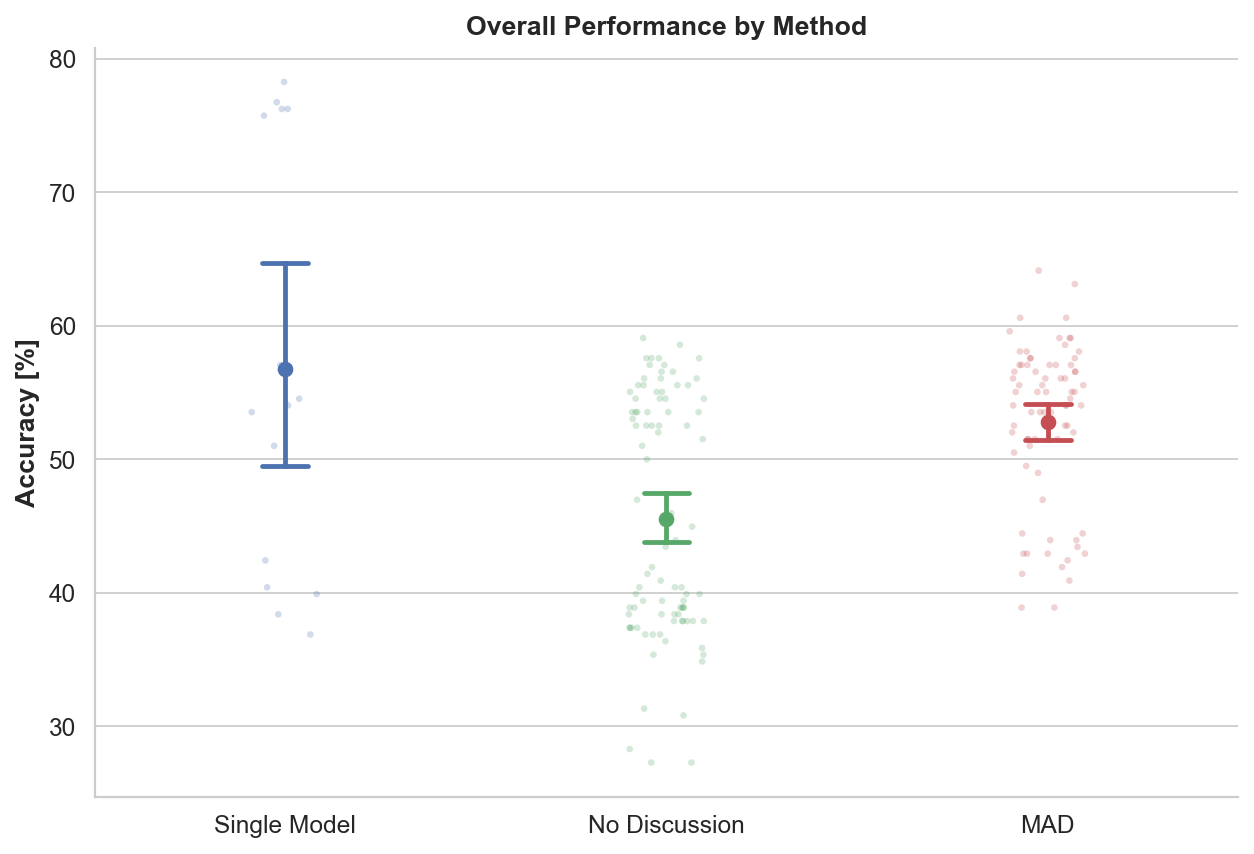

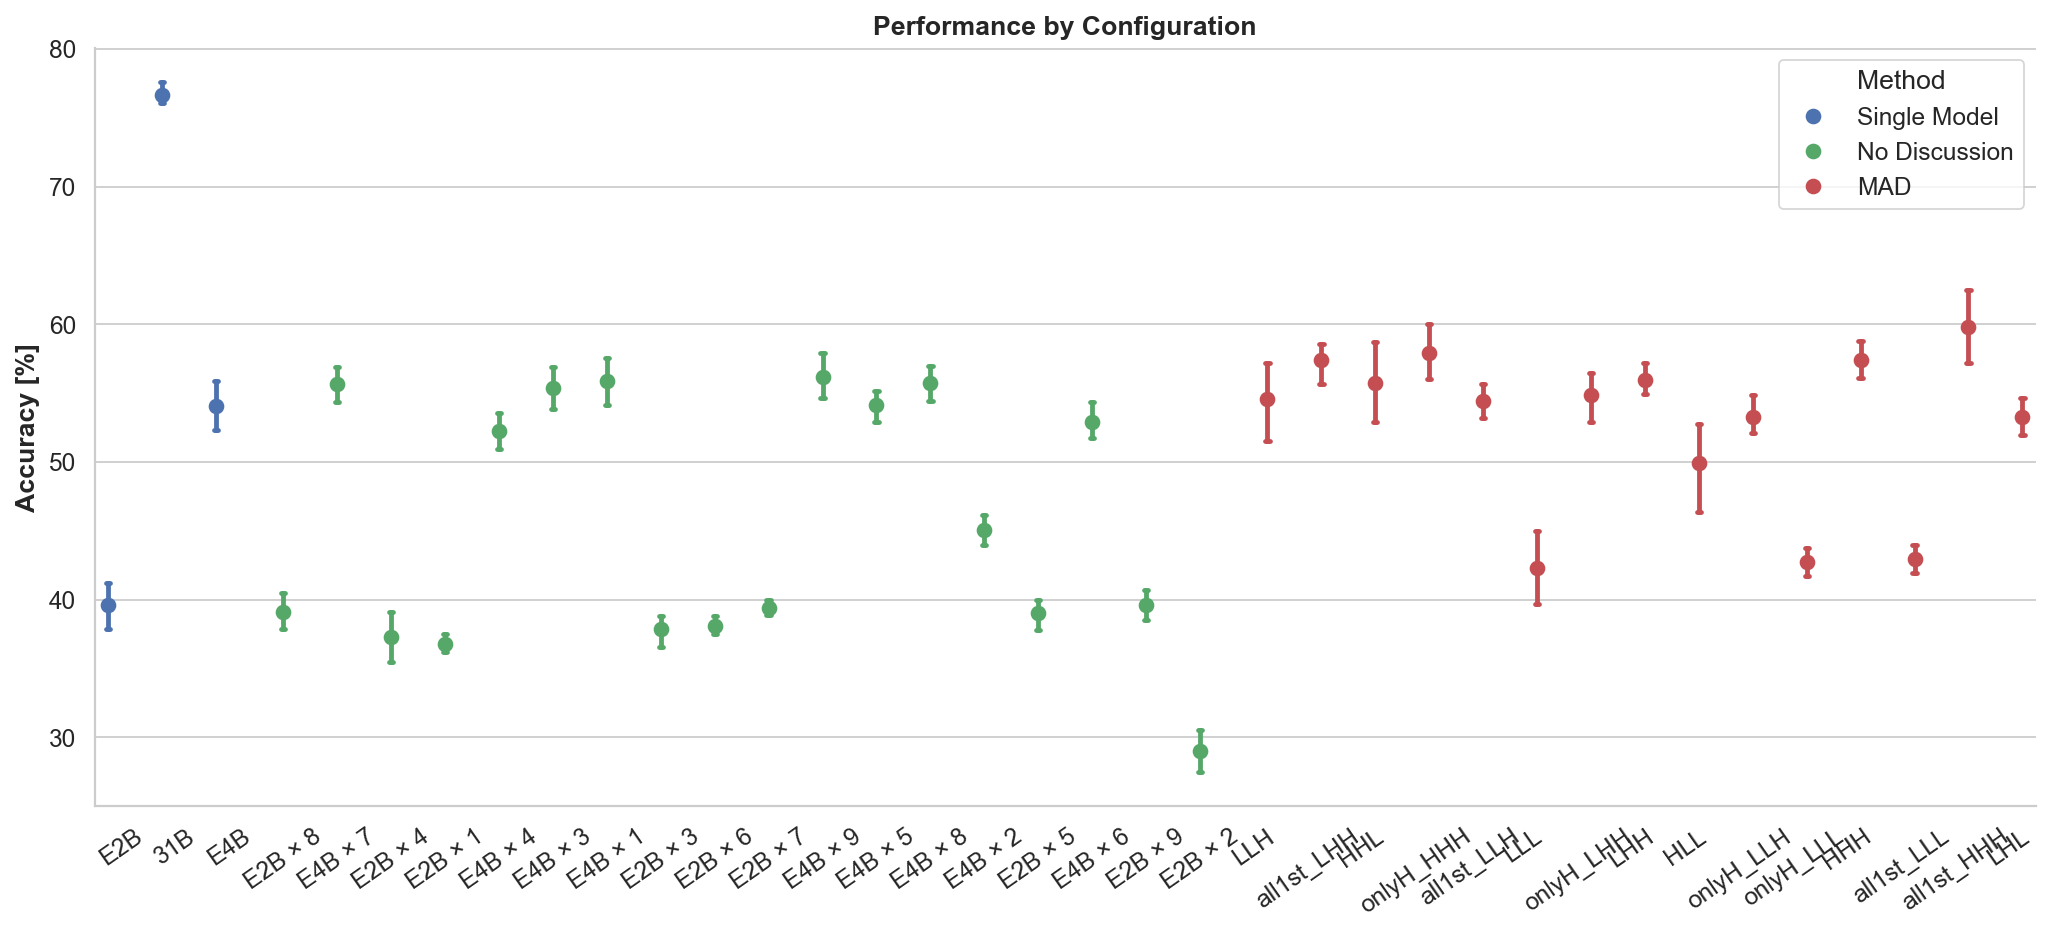

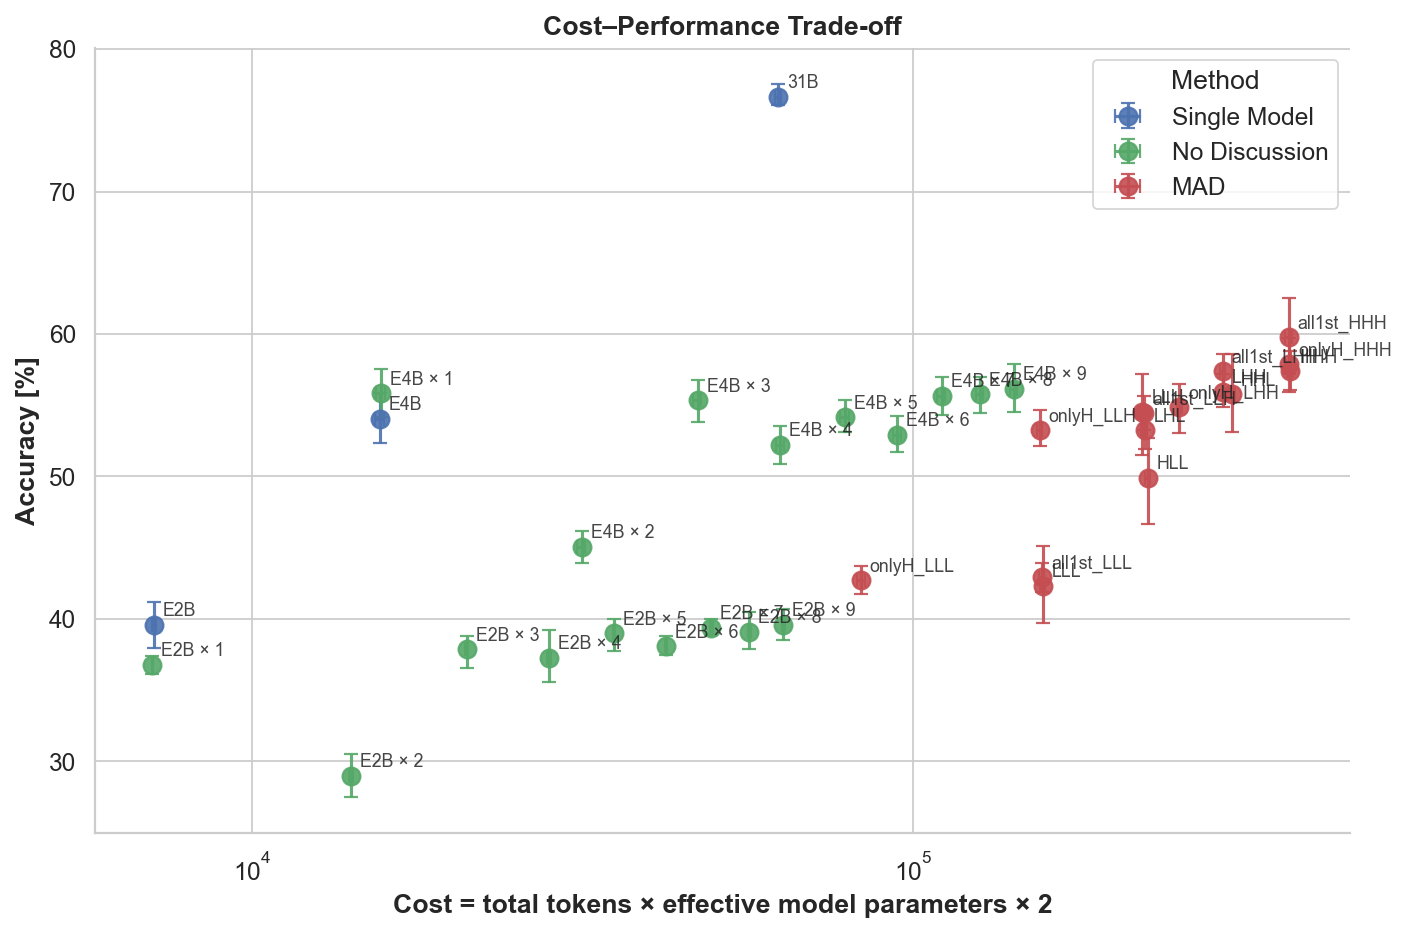

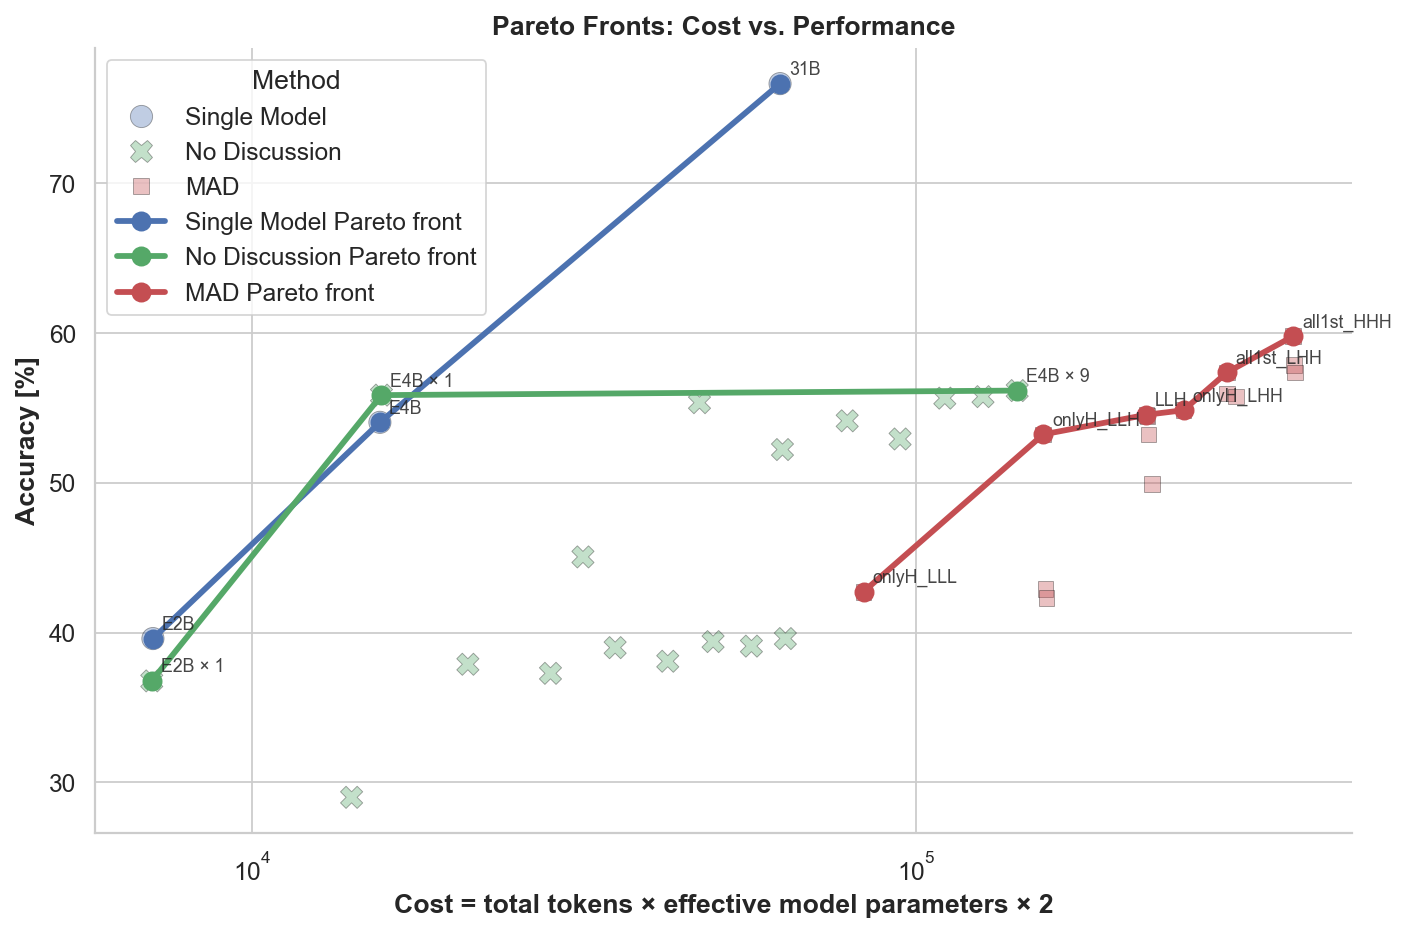

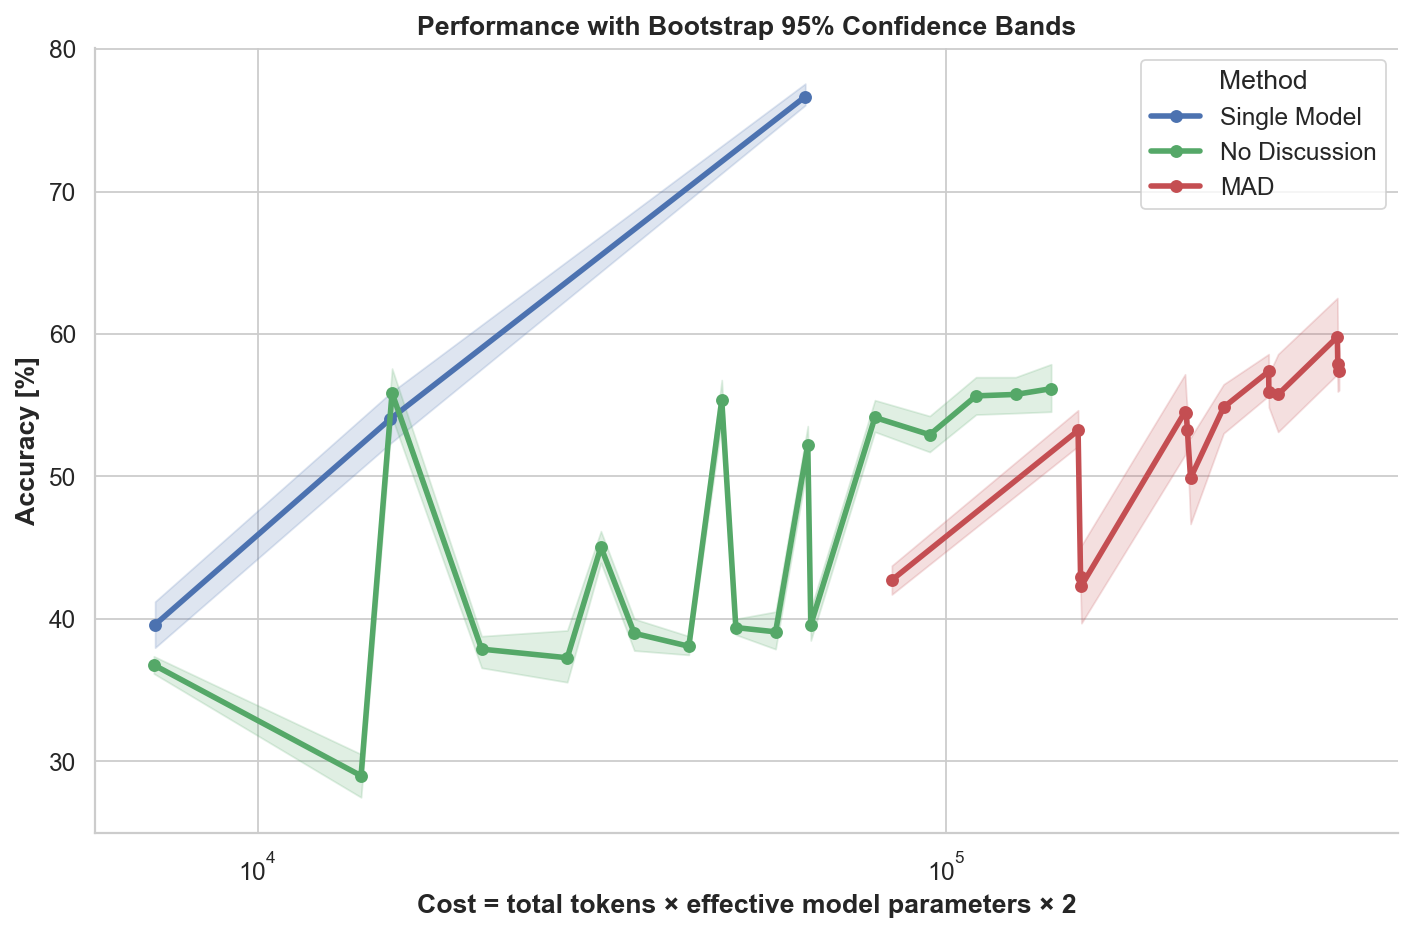

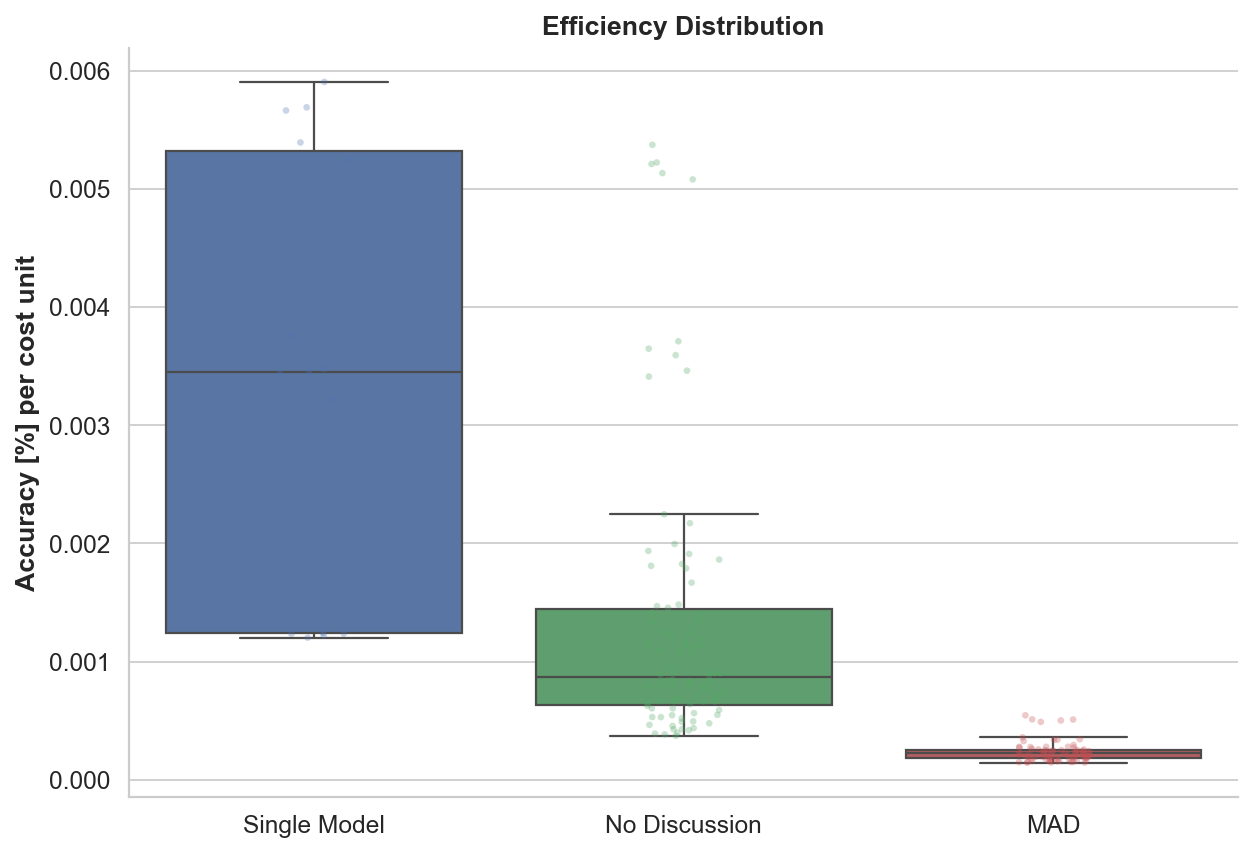

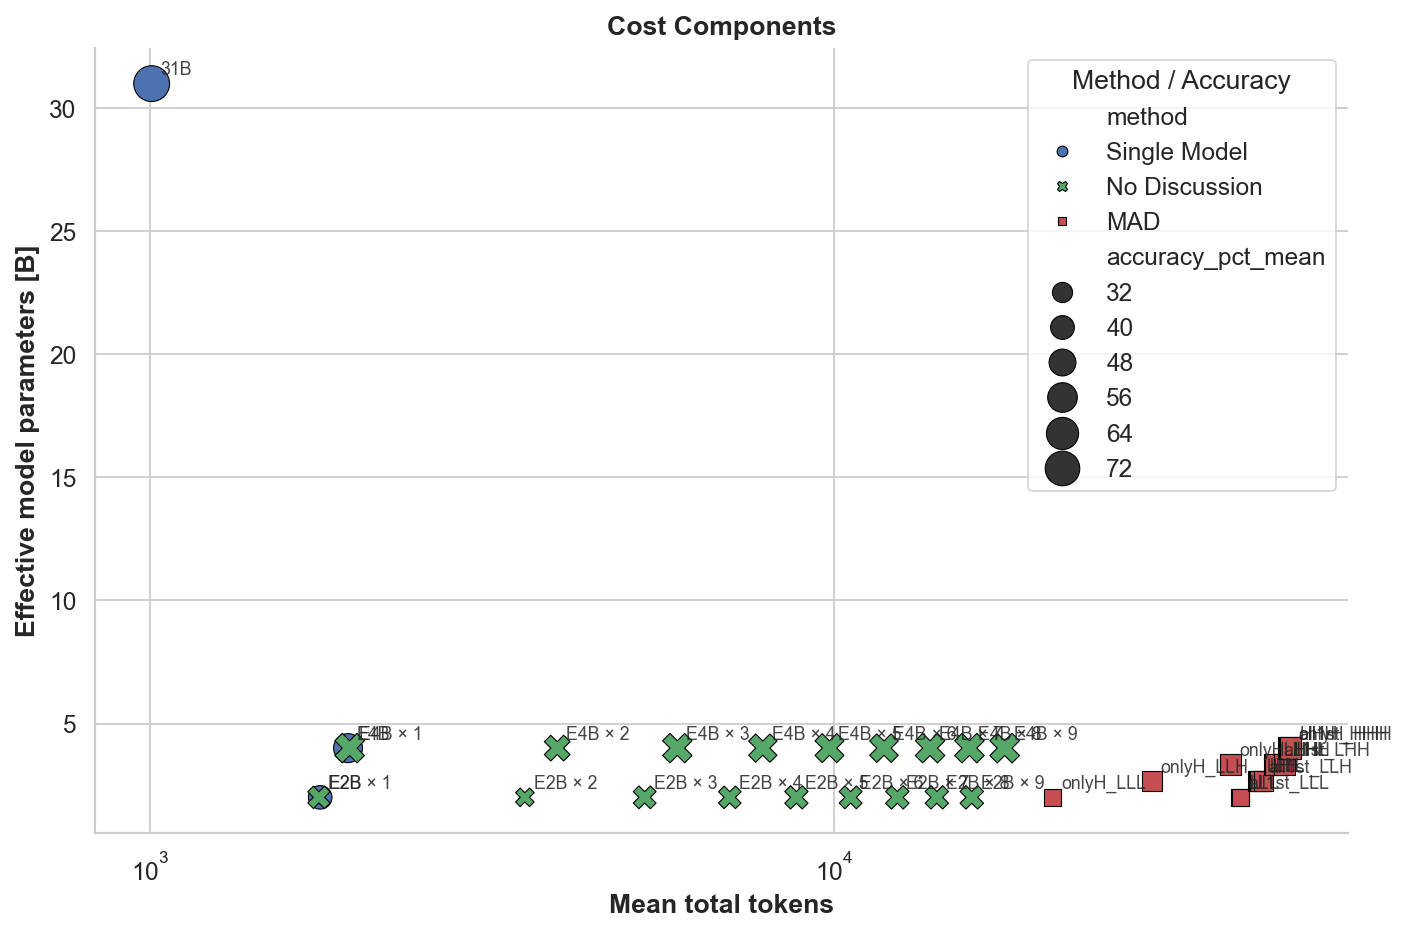

,method,setting,accuracy_mean,accuracy_pct_mean,accuracy_pct_low,accuracy_pct_high,cost_mean,cost_low,cost_high,total_tokens_mean,effective_params_b_mean,n_seeds
34,Single Model,E2B,0.395960,39.595960,37.979798,41.212121,7095.935354,7047.381818,7145.442424,1773.983838,2.000000,5
35,Single Model,E4B,0.540404,54.040404,52.323232,55.858586,15585.640404,15346.189899,15813.220202,1948.205051,4.000000,5
33,Single Model,31B,0.766667,76.666667,76.060606,77.575758,62391.852525,61872.743434,62972.523232,1006.320202,31.000000,5
15,No Discussion,E2B × 1,0.367677,36.767677,36.161616,37.373737,7066.860606,7056.795152,7078.480808,1766.715152,2.000000,5
16,No Discussion,E2B × 2,0.289899,28.989899,27.474747,30.505051,14128.739394,14021.111111,14217.397980,3532.184848,2.000000,5
24,No Discussion,E4B × 1,0.558586,55.858586,54.141414,57.575758,15670.997980,15377.341414,15895.628283,1958.874747,4.000000,5
17,No Discussion,E2B × 3,0.378788,37.878788,36.565657,38.787879,21141.745455,20994.448485,21244.024242,5285.436364,2.000000,5
18,No Discussion,E2B × 4,0.372727,37.272727,35.555556,39.191919,28151.212121,27967.151515,28324.937374,7037.803030,2.000000,5
25,No Discussion,E4B × 2,0.450505,45.050505,43.939394,46.161616,31503.660606,31031.612121,31910.901010,3937.957576,4.000000,5
19,No Discussion,E2B × 5,0.389899,38.989899,37.777778,40.000000,35222.953535,35083.935354,35349.907071,8805.738384,2.000000,5


In [14]:
# pip install polars pandas numpy seaborn matplotlib scipy

import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt


# =========================
# Global style
# =========================

sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.25,
    rc={
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "legend.frameon": True,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    },
)

PARAMS_BILLIONS = {
    "E2B": 2,
    "E4B": 4,
    "31B": 31,
}

METHOD_ORDER = [
    "Single Model",
    "No Discussion",
    "MAD",
]

PALETTE = {
    "Single Model": "#4C72B0",
    "No Discussion": "#55A868",
    "MAD": "#C44E52",
}


# =========================
# Helpers
# =========================


def extract_model_sizes(value):
    """
    Extracts model sizes such as E2B, E4B, 31B from strings/lists.

    Examples:
    - "E2B"
    - "gemma4 E2B"
    - "['E2B', 'E4B', '31B']"
    - "E2B-E4B-31B"
    """
    if isinstance(value, (list, tuple)):
        raw = " ".join(map(str, value))
    else:
        raw = str(value)

    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, (list, tuple)):
            raw = " ".join(map(str, parsed))
    except Exception:
        pass

    models = re.findall(r"(E2B|E4B|31B)", raw)

    if not models:
        raise ValueError(f"Could not infer model size from: {value}")

    return models


def model_params_sum(value):
    models = extract_model_sizes(value)
    return sum(PARAMS_BILLIONS[m] for m in models)


def model_params_average(value):
    models = extract_model_sizes(value)
    return np.mean([PARAMS_BILLIONS[m] for m in models])


def bootstrap_ci(values, statistic=np.mean, n_boot=5000, ci=95, seed=42):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan, np.nan

    if len(values) == 1:
        stat = statistic(values)
        return stat, stat

    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    stats = np.apply_along_axis(statistic, 1, samples)

    alpha = (100 - ci) / 2
    return np.percentile(stats, alpha), np.percentile(stats, 100 - alpha)


# =========================
# Data preparation
# =========================


def prepare_results(
    mad_result: pl.DataFrame,
    no_discussion_result: pl.DataFrame,
    single_model_result: pl.DataFrame,
):
    single = single_model_result.to_pandas()
    single["method"] = "Single Model"
    single["setting"] = single["model_size"].astype(str)
    single["effective_params_b"] = single["model_size"].apply(model_params_sum)

    nodisc = no_discussion_result.to_pandas()
    nodisc["method"] = "No Discussion"
    nodisc["setting"] = (
        nodisc["model_size"].astype(str) + " × " + nodisc["no_participants"].astype(str)
    )
    nodisc["effective_params_b"] = nodisc["model_size"].apply(model_params_sum)

    mad = mad_result.to_pandas()
    mad["method"] = "MAD"
    mad["setting"] = mad["group_constellation"].astype(str)
    mad["effective_params_b"] = mad["model_sizes"].apply(model_params_average)

    common_cols = [
        "seed",
        "method",
        "setting",
        "accuracy",
        "used_input_tokens",
        "used_output_tokens",
        "effective_params_b",
    ]

    df = pd.concat(
        [
            single[common_cols],
            nodisc[common_cols],
            mad[common_cols],
        ],
        ignore_index=True,
    )

    df["total_tokens"] = df["used_input_tokens"] + df["used_output_tokens"]

    # Main cost definition used everywhere:
    # total tokens × average/single model parameters × 2
    df["cost"] = df["total_tokens"] * df["effective_params_b"] * 2

    df["accuracy_pct"] = 100 * df["accuracy"]

    return df


# =========================
# Aggregation
# =========================


def aggregate_for_plotting(df, n_boot=5000):
    rows = []

    group_cols = ["method", "setting"]

    for keys, part in df.groupby(group_cols):
        method, setting = keys

        acc_low, acc_high = bootstrap_ci(
            part["accuracy_pct"],
            n_boot=n_boot,
        )

        cost_low, cost_high = bootstrap_ci(
            part["cost"],
            n_boot=n_boot,
        )

        rows.append(
            {
                "method": method,
                "setting": setting,
                "accuracy_mean": part["accuracy"].mean(),
                "accuracy_pct_mean": part["accuracy_pct"].mean(),
                "accuracy_pct_low": acc_low,
                "accuracy_pct_high": acc_high,
                "cost_mean": part["cost"].mean(),
                "cost_low": cost_low,
                "cost_high": cost_high,
                "total_tokens_mean": part["total_tokens"].mean(),
                "effective_params_b_mean": part["effective_params_b"].mean(),
                "n_seeds": part["seed"].nunique(),
            }
        )

    agg = pd.DataFrame(rows)
    agg["method"] = pd.Categorical(
        agg["method"],
        categories=METHOD_ORDER,
        ordered=True,
    )

    return agg.sort_values(["method", "cost_mean"])


def pareto_front(
    df,
    cost_col="cost_mean",
    perf_col="accuracy_pct_mean",
):
    """
    Minimizes cost and maximizes performance.
    """
    d = df.sort_values([cost_col, perf_col], ascending=[True, False]).copy()

    best_so_far = -np.inf
    keep = []

    for _, row in d.iterrows():
        if row[perf_col] > best_so_far:
            keep.append(True)
            best_so_far = row[perf_col]
        else:
            keep.append(False)

    return d.loc[keep].copy()


# =========================
# Plotting utilities
# =========================


def savefig(path):
    if path is not None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, bbox_inches="tight")


def add_point_labels(
    ax,
    data,
    x="cost_mean",
    y="accuracy_pct_mean",
    label="setting",
    fontsize=8,
):
    for _, r in data.iterrows():
        ax.annotate(
            str(r[label]),
            xy=(r[x], r[y]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=fontsize,
            alpha=0.85,
        )


# =========================
# Plots
# =========================


def plot_accuracy_by_method(df, save_path=None):
    plt.figure(figsize=(8, 5.5))

    ax = sns.pointplot(
        data=df,
        x="method",
        y="accuracy_pct",
        order=METHOD_ORDER,
        hue="method",
        hue_order=METHOD_ORDER,
        palette=PALETTE,
        errorbar=("ci", 95),
        capsize=0.12,
        markers="o",
        linestyles="none",
        dodge=False,
    )

    sns.stripplot(
        data=df,
        x="method",
        y="accuracy_pct",
        order=METHOD_ORDER,
        hue="method",
        hue_order=METHOD_ORDER,
        palette=PALETTE,
        dodge=False,
        alpha=0.25,
        size=3,
        ax=ax,
        legend=False,
    )

    ax.set_title("Overall Performance by Method")
    ax.set_xlabel("")
    ax.set_ylabel("Accuracy [%]")

    if ax.get_legend():
        ax.get_legend().remove()

    plt.tight_layout()
    savefig(save_path)
    plt.show()


def plot_accuracy_by_setting(df, save_path=None):
    plt.figure(figsize=(13, 6))

    ax = sns.pointplot(
        data=df,
        x="setting",
        y="accuracy_pct",
        hue="method",
        hue_order=METHOD_ORDER,
        palette=PALETTE,
        errorbar=("ci", 95),
        dodge=0.5,
        capsize=0.08,
        markers="o",
        linestyles="none",
    )

    ax.set_title("Performance by Configuration")
    ax.set_xlabel("")
    ax.set_ylabel("Accuracy [%]")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Method", loc="best")

    plt.tight_layout()
    savefig(save_path)
    plt.show()


def plot_cost_vs_performance(df, save_path=None, label_points=True):
    agg = aggregate_for_plotting(df)

    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    for method in METHOD_ORDER:
        part = agg[agg["method"] == method]
        if part.empty:
            continue

        ax.errorbar(
            part["cost_mean"],
            part["accuracy_pct_mean"],
            xerr=[
                part["cost_mean"] - part["cost_low"],
                part["cost_high"] - part["cost_mean"],
            ],
            yerr=[
                part["accuracy_pct_mean"] - part["accuracy_pct_low"],
                part["accuracy_pct_high"] - part["accuracy_pct_mean"],
            ],
            fmt="o",
            markersize=8,
            capsize=3,
            linewidth=1.4,
            color=PALETTE[method],
            label=method,
            alpha=0.9,
        )

    if label_points:
        add_point_labels(ax, agg)

    ax.set_xscale("log")
    ax.set_title("Cost–Performance Trade-off")
    ax.set_xlabel("Cost = total tokens × effective model parameters × 2")
    ax.set_ylabel("Accuracy [%]")
    ax.legend(title="Method")

    plt.tight_layout()
    savefig(save_path)
    plt.show()


def plot_pareto_fronts(df, save_path=None, label_points=True):
    agg = aggregate_for_plotting(df)

    fronts = []
    for method, part in agg.groupby("method", observed=True):
        f = pareto_front(part)
        f["is_pareto"] = True
        fronts.append(f)

    fronts = pd.concat(fronts, ignore_index=True)

    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    sns.scatterplot(
        data=agg,
        x="cost_mean",
        y="accuracy_pct_mean",
        hue="method",
        hue_order=METHOD_ORDER,
        palette=PALETTE,
        style="method",
        s=100,
        alpha=0.35,
        edgecolor="black",
        linewidth=0.4,
        ax=ax,
    )

    for method in METHOD_ORDER:
        f = fronts[fronts["method"] == method].sort_values("cost_mean")
        if f.empty:
            continue

        ax.plot(
            f["cost_mean"],
            f["accuracy_pct_mean"],
            marker="o",
            linewidth=2.6,
            markersize=8,
            color=PALETTE[method],
            label=f"{method} Pareto front",
        )

    if label_points:
        add_point_labels(ax, fronts)

    ax.set_xscale("log")
    ax.set_title("Pareto Fronts: Cost vs. Performance")
    ax.set_xlabel("Cost = total tokens × effective model parameters × 2")
    ax.set_ylabel("Accuracy [%]")

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), title="Method")

    plt.tight_layout()
    savefig(save_path)
    plt.show()


def plot_confidence_bands_over_cost(df, save_path=None):
    agg = aggregate_for_plotting(df)

    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    for method in METHOD_ORDER:
        part = agg[agg["method"] == method].sort_values("cost_mean")
        if part.empty:
            continue

        ax.plot(
            part["cost_mean"],
            part["accuracy_pct_mean"],
            marker="o",
            linewidth=2.5,
            label=method,
            color=PALETTE[method],
        )

        ax.fill_between(
            part["cost_mean"].to_numpy(),
            part["accuracy_pct_low"].to_numpy(),
            part["accuracy_pct_high"].to_numpy(),
            alpha=0.18,
            color=PALETTE[method],
        )

    ax.set_xscale("log")
    ax.set_title("Performance with Bootstrap 95% Confidence Bands")
    ax.set_xlabel("Cost = total tokens × effective model parameters × 2")
    ax.set_ylabel("Accuracy [%]")
    ax.legend(title="Method")

    plt.tight_layout()
    savefig(save_path)
    plt.show()


def plot_efficiency_distribution(df, save_path=None):
    plot_df = df.copy()
    plot_df["accuracy_per_cost"] = plot_df["accuracy_pct"] / plot_df["cost"]

    plt.figure(figsize=(8, 5.5))

    ax = sns.boxplot(
        data=plot_df,
        x="method",
        y="accuracy_per_cost",
        order=METHOD_ORDER,
        hue="method",
        palette=PALETTE,
        showfliers=False,
    )

    sns.stripplot(
        data=plot_df,
        x="method",
        y="accuracy_per_cost",
        order=METHOD_ORDER,
        hue="method",
        palette=PALETTE,
        alpha=0.3,
        size=3,
        ax=ax,
        legend=False,
    )

    ax.set_title("Efficiency Distribution")
    ax.set_xlabel("")
    ax.set_ylabel("Accuracy [%] per cost unit")

    if ax.get_legend():
        ax.get_legend().remove()

    plt.tight_layout()
    savefig(save_path)
    plt.show()


def plot_cost_breakdown(df, save_path=None):
    agg = aggregate_for_plotting(df)

    plt.figure(figsize=(9, 6))

    ax = sns.scatterplot(
        data=agg,
        x="total_tokens_mean",
        y="effective_params_b_mean",
        hue="method",
        hue_order=METHOD_ORDER,
        palette=PALETTE,
        style="method",
        size="accuracy_pct_mean",
        sizes=(70, 260),
        edgecolor="black",
        linewidth=0.5,
    )

    add_point_labels(
        ax,
        agg,
        x="total_tokens_mean",
        y="effective_params_b_mean",
        fontsize=8,
    )

    ax.set_xscale("log")
    ax.set_title("Cost Components")
    ax.set_xlabel("Mean total tokens")
    ax.set_ylabel("Effective model parameters [B]")
    ax.legend(title="Method / Accuracy")

    plt.tight_layout()
    savefig(save_path)
    plt.show()


# =========================
# Main runner
# =========================


def plot_all_thesis_figures(
    mad_result,
    no_discussion_result,
    single_model_result,
    output_dir="figures",
    file_format="pdf",
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    df = prepare_results(
        mad_result=mad_result,
        no_discussion_result=no_discussion_result,
        single_model_result=single_model_result,
    )

    summary = aggregate_for_plotting(df)

    plot_accuracy_by_method(
        df,
        save_path=output_dir / f"accuracy_by_method.{file_format}",
    )

    plot_accuracy_by_setting(
        df,
        save_path=output_dir / f"accuracy_by_setting.{file_format}",
    )

    plot_cost_vs_performance(
        df,
        save_path=output_dir / f"cost_vs_performance.{file_format}",
    )

    plot_pareto_fronts(
        df,
        save_path=output_dir / f"pareto_fronts.{file_format}",
    )

    plot_confidence_bands_over_cost(
        df,
        save_path=output_dir / f"confidence_bands_over_cost.{file_format}",
    )

    plot_efficiency_distribution(
        df,
        save_path=output_dir / f"efficiency_distribution.{file_format}",
    )

    plot_cost_breakdown(
        df,
        save_path=output_dir / f"cost_breakdown.{file_format}",
    )

    return df, summary


# =========================
# Usage
# =========================

df_all, df_summary = plot_all_thesis_figures(
    mad_result=mad_result,
    no_discussion_result=no_discussion_result,
    single_model_result=single_model_result,
    output_dir="figures",
    file_format="pdf",
)

df_summary

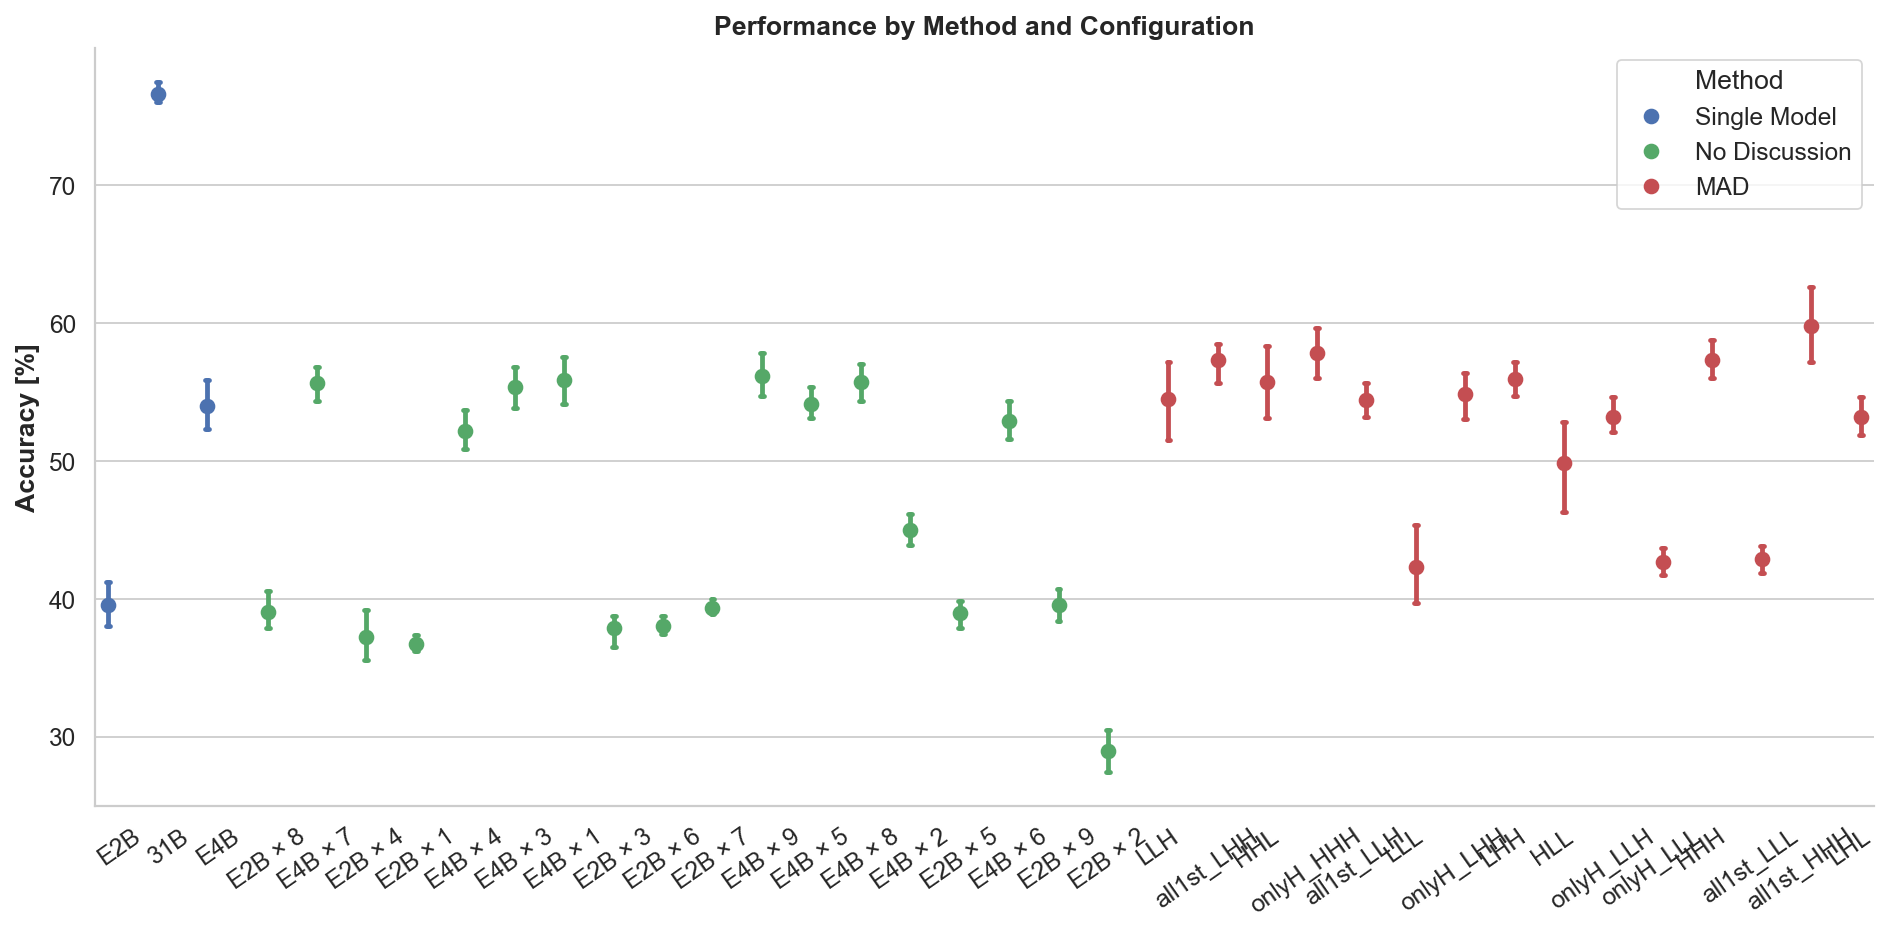

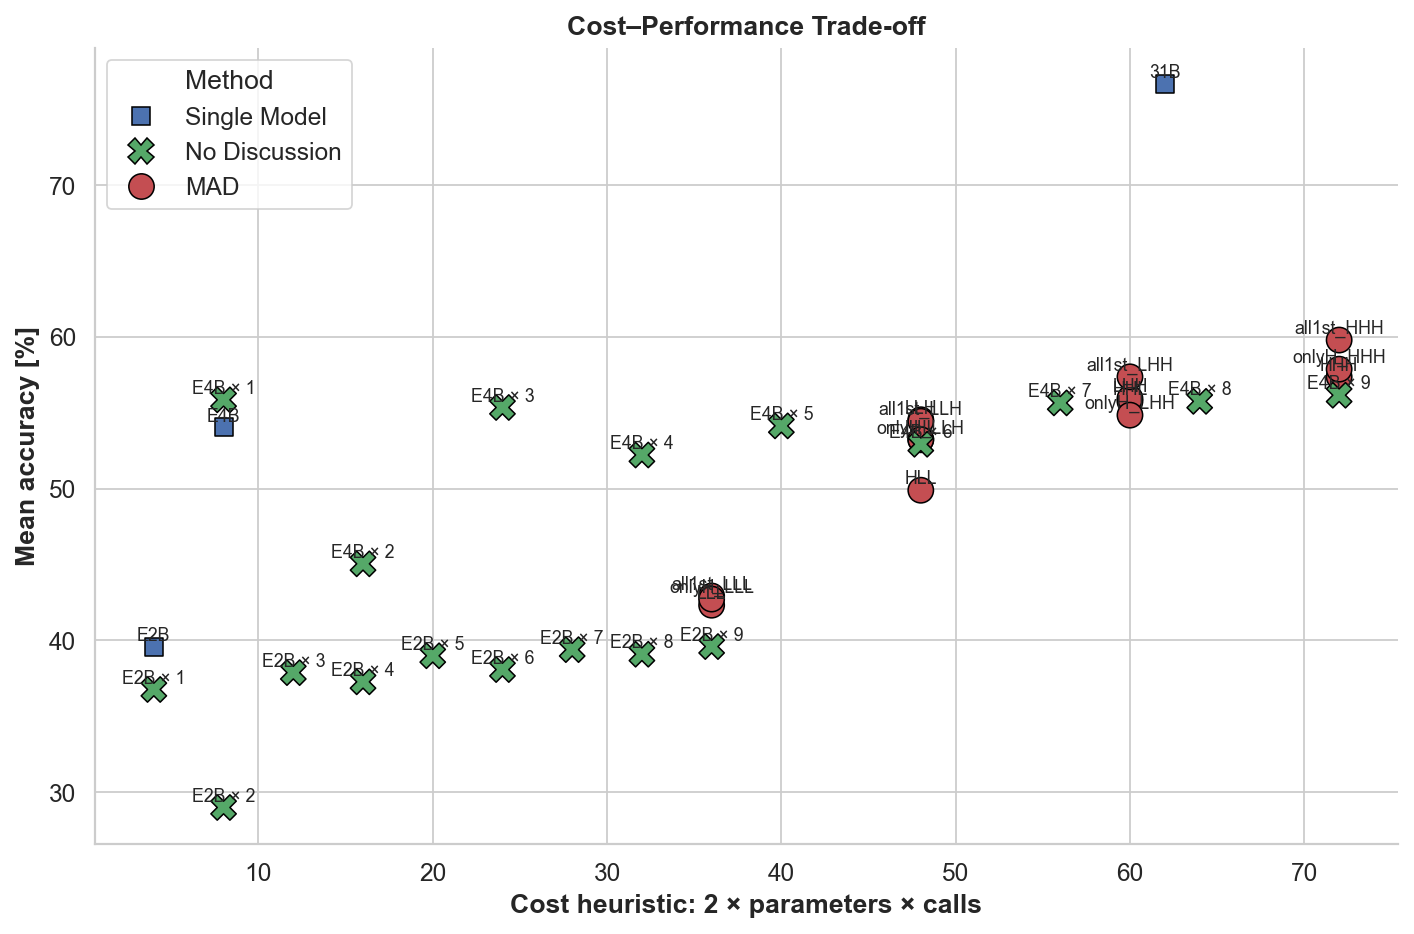

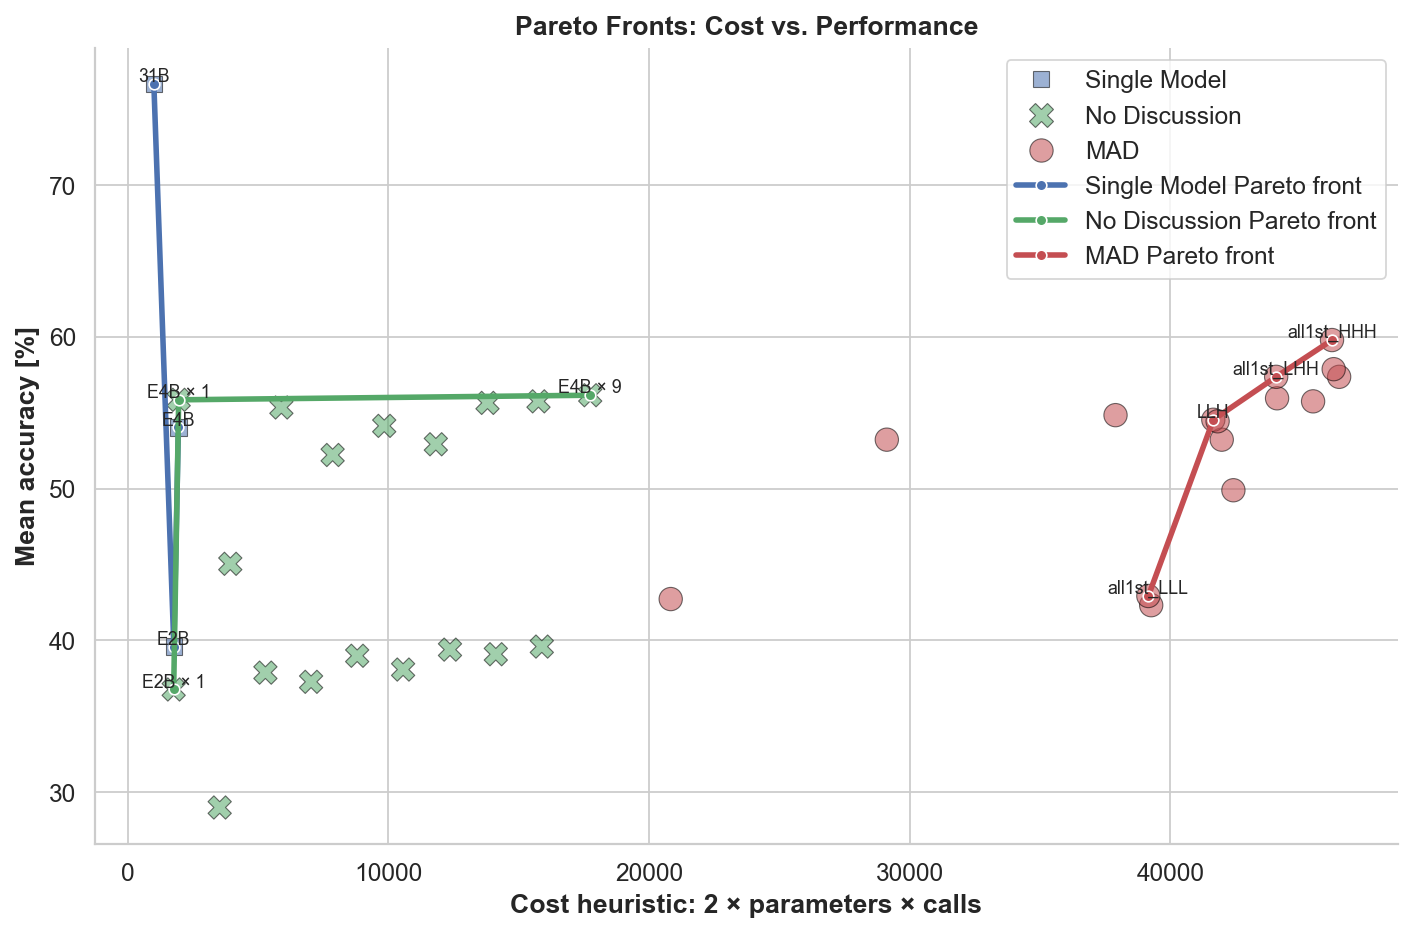

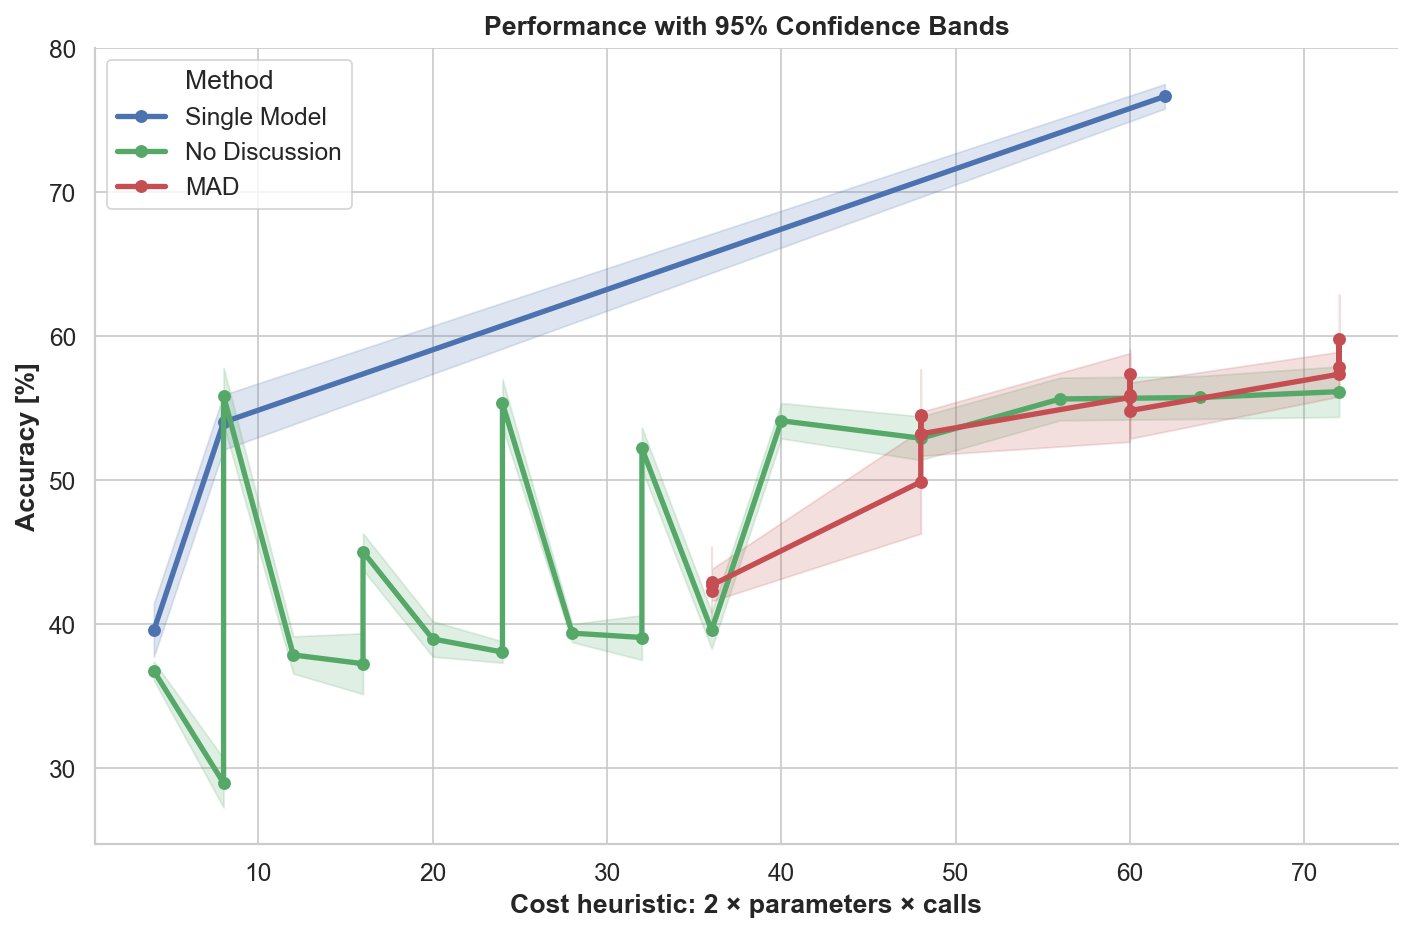

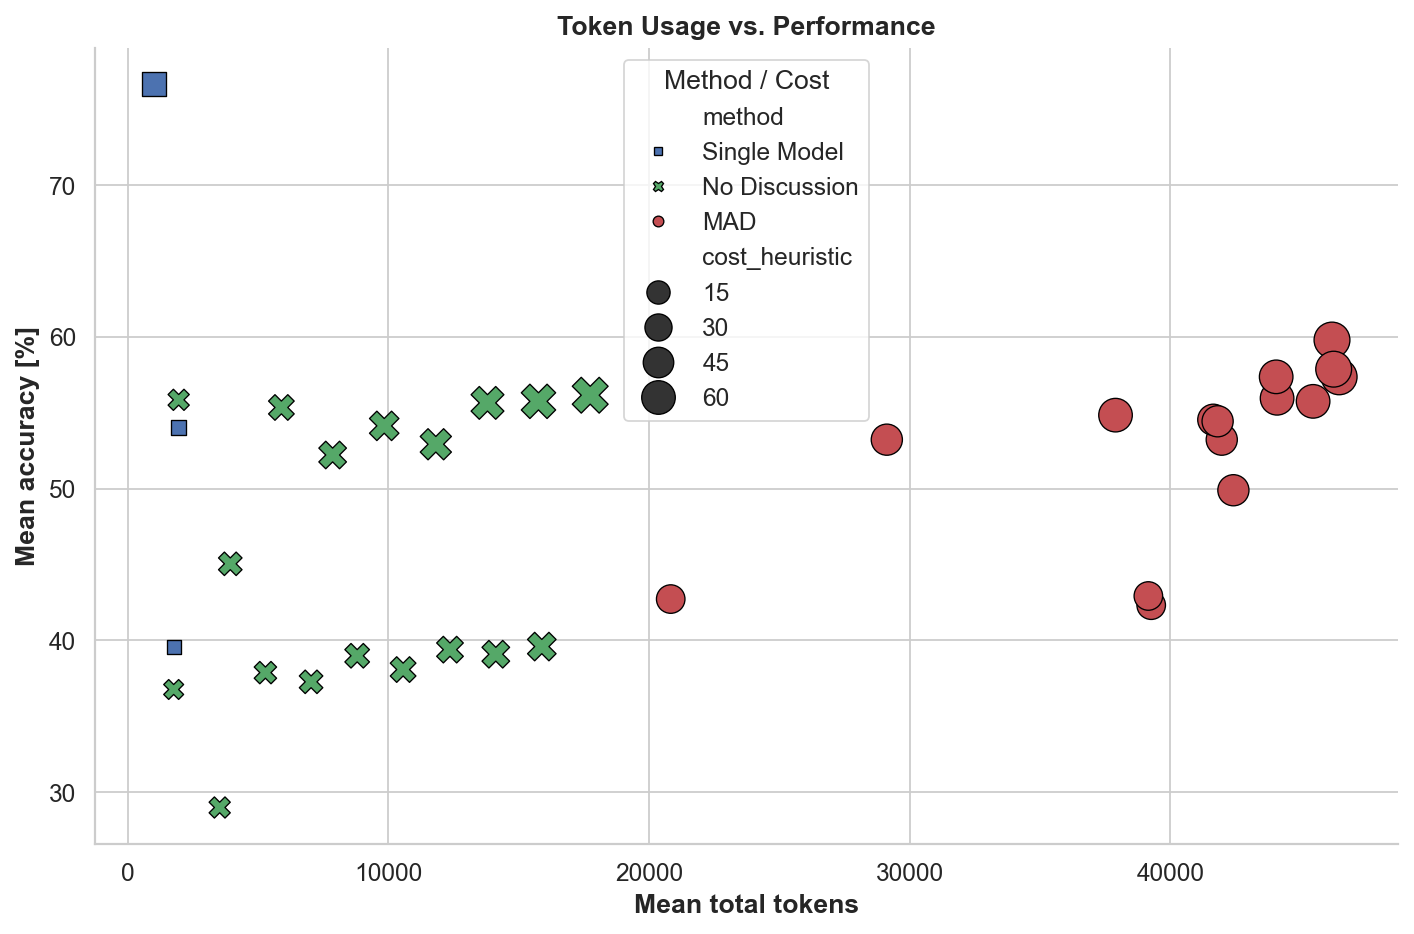

In [15]:
# pip install polars pandas seaborn matplotlib numpy scipy

import re
import ast
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.25,
    rc={
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "legend.frameon": True,
    },
)

PARAMS = {
    "E2B": 2,
    "E4B": 4,
    "31B": 31,
}

METHOD_ORDER = [
    "Single Model",
    "No Discussion",
    "MAD",
]

PALETTE = {
    "Single Model": "#4C72B0",
    "No Discussion": "#55A868",
    "MAD": "#C44E52",
}


def _extract_model_sizes(text):
    """
    Extracts model sizes such as E2B, E4B, 31B from strings/lists.
    Works with values like:
    - "E2B"
    - "gemma4 E2B"
    - "['E2B', 'E4B', '31B']"
    - "E2B-E4B-31B"
    """
    if isinstance(text, (list, tuple)):
        raw = " ".join(map(str, text))
    else:
        raw = str(text)

    # Try parsing stringified lists first
    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, (list, tuple)):
            raw = " ".join(map(str, parsed))
    except Exception:
        pass

    return re.findall(r"(E2B|E4B|31B)", raw)


def _params_for_model_size(model_size):
    models = _extract_model_sizes(model_size)
    if not models:
        raise ValueError(f"Could not infer model size from: {model_size}")
    return sum(PARAMS[m] for m in models)


def prepare_results(
    mad_result: pl.DataFrame,
    no_discussion_result: pl.DataFrame,
    single_model_result: pl.DataFrame,
):
    # Single-model baseline
    single = single_model_result.to_pandas()
    single["method"] = "Single Model"
    single["setting"] = single["model_size"]
    single["cost_heuristic"] = single["model_size"].apply(
        lambda x: 2 * _params_for_model_size(x)
    )

    # No-discussion multi-agent baseline
    nodisc = no_discussion_result.to_pandas()
    nodisc["method"] = "No Discussion"
    nodisc["setting"] = (
        nodisc["model_size"].astype(str) + " × " + nodisc["no_participants"].astype(str)
    )
    nodisc["cost_heuristic"] = nodisc.apply(
        lambda r: 2 * _params_for_model_size(r["model_size"]) * r["no_participants"],
        axis=1,
    )

    # MAD
    mad = mad_result.to_pandas()
    mad["method"] = "MAD"
    mad["setting"] = mad["group_constellation"]
    mad["model_count"] = mad["model_sizes"].apply(
        lambda x: len(_extract_model_sizes(x))
    )
    mad["cost_heuristic"] = mad["model_sizes"].apply(
        lambda x: 3 * 2 * _params_for_model_size(x)
    )

    common_cols = [
        "seed",
        "method",
        "setting",
        "accuracy",
        "used_input_tokens",
        "used_output_tokens",
        "cost_heuristic",
    ]

    df = pd.concat(
        [
            single[common_cols],
            nodisc[common_cols],
            mad[common_cols],
        ],
        ignore_index=True,
    )

    df["total_tokens"] = df["used_input_tokens"] + df["used_output_tokens"]
    df["accuracy_pct"] = 100 * df["accuracy"]

    return df


def aggregate_for_plotting(df):
    return (
        df.groupby(["method", "setting", "cost_heuristic"], as_index=False)
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            accuracy_sem=("accuracy", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
            accuracy_pct_mean=("accuracy_pct", "mean"),
            total_tokens_mean=("total_tokens", "mean"),
            input_tokens_mean=("used_input_tokens", "mean"),
            output_tokens_mean=("used_output_tokens", "mean"),
            n_seeds=("seed", "nunique"),
        )
        .assign(
            accuracy_ci95=lambda x: 1.96 * x["accuracy_sem"],
            accuracy_pct_ci95=lambda x: 100 * x["accuracy_ci95"],
        )
    )


def pareto_front(df, cost_col="cost_heuristic", perf_col="accuracy_mean"):
    """
    Minimizes cost, maximizes performance.
    """
    d = df.sort_values([cost_col, perf_col], ascending=[True, False]).copy()

    best_so_far = -np.inf
    keep = []

    for _, row in d.iterrows():
        if row[perf_col] > best_so_far:
            keep.append(True)
            best_so_far = row[perf_col]
        else:
            keep.append(False)

    return d.loc[keep]


def plot_accuracy_by_setting(df, save_path=None):
    plt.figure(figsize=(12, 6))

    ax = sns.pointplot(
        data=df,
        x="setting",
        y="accuracy_pct",
        hue="method",
        hue_order=METHOD_ORDER,
        palette=PALETTE,
        errorbar=("ci", 95),
        dodge=0.45,
        capsize=0.08,
        markers="o",
        linestyles="none",
    )

    ax.set_title("Performance by Method and Configuration")
    ax.set_xlabel("")
    ax.set_ylabel("Accuracy [%]")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Method", loc="best")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


def plot_cost_vs_performance(df, save_path=None):
    agg = aggregate_for_plotting(df)

    plt.figure(figsize=(9, 6))

    ax = sns.scatterplot(
        data=agg,
        x="cost_heuristic",
        y="accuracy_pct_mean",
        hue="method",
        hue_order=METHOD_ORDER,
        palette=PALETTE,
        style="method",
        s=130,
        edgecolor="black",
        linewidth=0.7,
    )

    for _, r in agg.iterrows():
        ax.text(
            r["cost_heuristic"],
            r["accuracy_pct_mean"] + 0.15,
            str(r["setting"]),
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_title("Cost–Performance Trade-off")
    ax.set_xlabel("Cost heuristic: 2 × parameters × calls")
    ax.set_ylabel("Mean accuracy [%]")
    ax.legend(title="Method")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


def plot_pareto_fronts(df, save_path=None, cost_metric="total_tokens_mean"):
    agg = aggregate_for_plotting(df)

    fronts = []
    for method, part in agg.groupby("method"):
        f = pareto_front(part)
        f["is_pareto"] = True
        fronts.append(f)

    fronts = pd.concat(fronts, ignore_index=True)

    plt.figure(figsize=(9, 6))

    ax = sns.scatterplot(
        data=agg,
        x=cost_metric,
        y="accuracy_pct_mean",
        hue="method",
        hue_order=METHOD_ORDER,
        palette=PALETTE,
        style="method",
        s=110,
        alpha=0.55,
        edgecolor="black",
        linewidth=0.5,
    )

    for method in METHOD_ORDER:
        f = fronts[fronts["method"] == method].sort_values(cost_metric)
        if len(f) > 0:
            sns.lineplot(
                data=f,
                x=cost_metric,
                y="accuracy_pct_mean",
                color=PALETTE[method],
                marker="o",
                linewidth=2.5,
                ax=ax,
                label=f"{method} Pareto front",
            )

    for _, r in fronts.iterrows():
        ax.text(
            r[cost_metric],
            r["accuracy_pct_mean"] + 0.15,
            str(r["setting"]),
            fontsize=8,
            ha="center",
        )

    ax.set_title("Pareto Fronts: Cost vs. Performance")
    ax.set_xlabel("Cost heuristic: 2 × parameters × calls")
    ax.set_ylabel("Mean accuracy [%]")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


def plot_confidence_bands_over_cost(df, save_path=None):
    agg = aggregate_for_plotting(df)

    plt.figure(figsize=(9, 6))
    ax = plt.gca()

    for method in METHOD_ORDER:
        part = agg[agg["method"] == method].sort_values("cost_heuristic")
        if part.empty:
            continue

        ax.plot(
            part["cost_heuristic"],
            part["accuracy_pct_mean"],
            marker="o",
            linewidth=2.4,
            label=method,
            color=PALETTE[method],
        )

        ax.fill_between(
            part["cost_heuristic"],
            part["accuracy_pct_mean"] - part["accuracy_pct_ci95"],
            part["accuracy_pct_mean"] + part["accuracy_pct_ci95"],
            alpha=0.18,
            color=PALETTE[method],
        )

    ax.set_title("Performance with 95% Confidence Bands")
    ax.set_xlabel("Cost heuristic: 2 × parameters × calls")
    ax.set_ylabel("Accuracy [%]")
    ax.legend(title="Method")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


def plot_token_cost_vs_performance(df, save_path=None):
    agg = aggregate_for_plotting(df)

    plt.figure(figsize=(9, 6))

    ax = sns.scatterplot(
        data=agg,
        x="total_tokens_mean",
        y="accuracy_pct_mean",
        hue="method",
        hue_order=METHOD_ORDER,
        palette=PALETTE,
        style="method",
        size="cost_heuristic",
        sizes=(80, 260),
        edgecolor="black",
        linewidth=0.6,
    )

    ax.set_title("Token Usage vs. Performance")
    ax.set_xlabel("Mean total tokens")
    ax.set_ylabel("Mean accuracy [%]")
    ax.legend(title="Method / Cost")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


def plot_all_thesis_figures(
    mad_result,
    no_discussion_result,
    single_model_result,
    output_dir=None,
):
    df = prepare_results(
        mad_result=mad_result,
        no_discussion_result=no_discussion_result,
        single_model_result=single_model_result,
    )

    prefix = "" if output_dir is None else output_dir.rstrip("/") + "/"

    plot_accuracy_by_setting(
        df,
        save_path=None if output_dir is None else prefix + "accuracy_by_setting.pdf",
    )

    plot_cost_vs_performance(
        df,
        save_path=None if output_dir is None else prefix + "cost_vs_performance.pdf",
    )

    plot_pareto_fronts(
        df,
        save_path=None if output_dir is None else prefix + "pareto_fronts.pdf",
    )

    plot_confidence_bands_over_cost(
        df,
        save_path=None
        if output_dir is None
        else prefix + "confidence_bands_over_cost.pdf",
    )

    plot_token_cost_vs_performance(
        df,
        save_path=None
        if output_dir is None
        else prefix + "token_cost_vs_performance.pdf",
    )

    return df, aggregate_for_plotting(df)


# Usage:
df_all, df_summary = plot_all_thesis_figures(
    mad_result,
    no_discussion_result,
    single_model_result,
    output_dir="figures",  # or None
)